# Phân tích bộ dữ liệu `Example`


## 1. Preparing datasets

>>> ĐANG TẢI VÀ XỬ LÝ DỮ LIỆU...
Đã xong! Tổng số mẫu sạch: 4153

>>> BẮT ĐẦU TASK: KHẢO SÁT TỶ LỆ TRAIN/TEST

[Tỷ lệ Train: 40.0% - Test: 60%]
-> Độ chính xác (Accuracy): 19.42%
-> Số lượng mẫu Train: 1661, Test: 2492

[Tỷ lệ Train: 60.0% - Test: 40%]
-> Độ chính xác (Accuracy): 21.72%
-> Số lượng mẫu Train: 2491, Test: 1662

[Tỷ lệ Train: 80.0% - Test: 20%]
-> Độ chính xác (Accuracy): 18.89%
-> Số lượng mẫu Train: 3322, Test: 831

[Tỷ lệ Train: 90.0% - Test: 10%]
-> Độ chính xác (Accuracy): 19.71%
-> Số lượng mẫu Train: 3737, Test: 416

>>> BẮT ĐẦU TASK: KHẢO SÁT ĐỘ SÂU (MAX_DEPTH)
Kết quả độ chính xác theo độ sâu:
Max Depth       | Accuracy  
------------------------------
None            | 18.89%
2               | 23.35%
3               | 23.83%
4               | 25.39%
5               | 23.35%
6               | 24.91%
7               | 23.71%


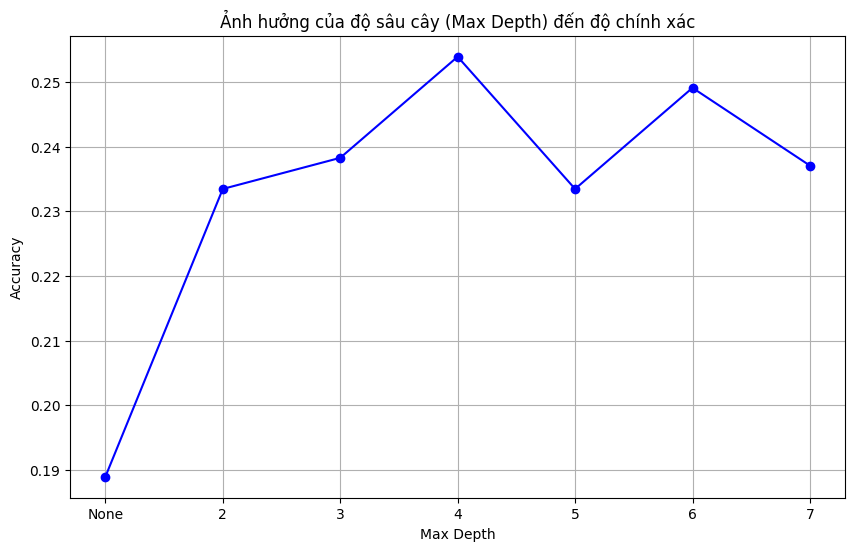

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score

# ==========================================
# PHẦN 1: CHUẨN BỊ DỮ LIỆU (DATA PREPARATION)
# ==========================================
print(">>> ĐANG TẢI VÀ XỬ LÝ DỮ LIỆU...")
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/abalone/abalone.data"
cols = ["Sex", "Length", "Diameter", "Height", "Whole_weight", 
        "Shucked_weight", "Viscera_weight", "Shell_weight", "Rings"]
df = pd.read_csv(url, header=None, names=cols)

# 1. One-Hot Encoding cho cột 'Sex' (Yêu cầu bắt buộc)
df_encoded = pd.get_dummies(df, columns=['Sex'], drop_first=False)

# 2. Lọc bỏ các lớp quá hiếm (để tránh lỗi khi chia tập train/test)
X = df_encoded.drop('Rings', axis=1)
y = df_encoded['Rings']
class_counts = y.value_counts()
valid_classes = class_counts[class_counts >= 10].index # Chỉ giữ lớp có >= 10 mẫu
mask = y.isin(valid_classes)
X_filtered = X[mask]
y_filtered = y[mask]
print(f"Đã xong! Tổng số mẫu sạch: {len(X_filtered)}")

# ==========================================
# PHẦN 2: CHẠY THỬ NGHIỆM CÁC TỶ LỆ (TASK 2.2)
# ==========================================
print("\n" + "="*40)
print(">>> BẮT ĐẦU TASK: KHẢO SÁT TỶ LỆ TRAIN/TEST")
print("="*40)

ratios = [0.4, 0.6, 0.8, 0.9] # Tỷ lệ tập Train: 40%, 60%, 80%, 90%

for ratio in ratios:
    # Chia dữ liệu
    X_train, X_test, y_train, y_test = train_test_split(
        X_filtered, y_filtered, train_size=ratio, stratify=y_filtered, random_state=42
    )
    
    # Huấn luyện mô hình
    clf = DecisionTreeClassifier(criterion='entropy', random_state=42)
    clf.fit(X_train, y_train)
    
    # Đánh giá
    acc = accuracy_score(y_test, clf.predict(X_test))
    print(f"\n[Tỷ lệ Train: {ratio*100}% - Test: {(1-ratio)*100:.0f}%]")
    print(f"-> Độ chính xác (Accuracy): {acc:.2%}")
    print(f"-> Số lượng mẫu Train: {len(X_train)}, Test: {len(X_test)}")

# ==========================================
# PHẦN 3: KHẢO SÁT ĐỘ SÂU CÂY (TASK 2.4)
# ==========================================
print("\n" + "="*40)
print(">>> BẮT ĐẦU TASK: KHẢO SÁT ĐỘ SÂU (MAX_DEPTH)")
print("="*40)

# Cố định tỷ lệ 80/20 cho bài này
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_filtered, train_size=0.8, stratify=y_filtered, random_state=42
)

depths = [None, 2, 3, 4, 5, 6, 7]
accuracies = []

print("Kết quả độ chính xác theo độ sâu:")
print(f"{'Max Depth':<15} | {'Accuracy':<10}")
print("-" * 30)

for d in depths:
    clf = DecisionTreeClassifier(criterion='entropy', max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    acc = accuracy_score(y_test, clf.predict(X_test))
    accuracies.append(acc)
    depth_name = str(d) if d is not None else "None"
    print(f"{depth_name:<15} | {acc:.2%}")

# Vẽ biểu đồ đường (Line Chart) biểu diễn độ chính xác
plt.figure(figsize=(10, 6))
plot_x = [str(d) if d is not None else "None" for d in depths]
plt.plot(plot_x, accuracies, marker='o', linestyle='-', color='b')
plt.title('Ảnh hưởng của độ sâu cây (Max Depth) đến độ chính xác')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

## 2. Building and Evaluating the decision tree classifiers


 **Có cần nếu có để biết print cho hiểu**

## 3. The depth and accuracy of a decision tree
